In [1]:
import os
import torch
import numpy as np
import torch.nn as nn
from tqdm import trange
from pathlib import Path
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from torchinfo import summary
import time
import sys
import pandas as pd
import sympy as sp
import scipy

import seaborn as sns
import sklearn.gaussian_process as gp
from scipy import stats

sys.path.append('../..')
sys.path.append('../../..')
sys.path.append('..')

sys.path.append('../nodes_2')

import plot_settings
plot_settings.apply()
COLORS = plot_settings.colors()
import importlib
#import multi_exp_log
import Param_symbol

import ecmm_vnode_vstatic_snode_sstatic_batch_lib_6 as _lib

from IPython.display import display, Math


def import_reload():
    #importlib.reload(multi_exp_log)
    importlib.reload(Param_symbol)
from ecmm_vnode_vstatic_snode_sstatic_batch_lib_6 import *
import_reload() 


/Users/noord/Desktop/MSc_git_new/MSc_thesis/program/venv/lib/python3.12/site-packages/juliacall/__init__.py:61: UserWarning: torch was imported before juliacall. This may cause a segfault. To avoid this, import juliacall before importing torch. For updates, see https://github.com/pytorch/pytorch/issues/78829.
  warnings.warn(


Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [2]:
RUN_ID = 'SP'
DT = 1
Q0 = 17921.57581 
SAVE  = False
ITS = int(1e1)

REF_VALUES = {
    'R0': 0.01,
    'R1': 0.01,
    'C1': 1000,
    'k':  0.01,
    's':  0.001,
    'sdot': 0.001
    }


VARIABLES = ['R0', 'R1', 'C1','k','s']
UNITS = {
    'R0': '$\Omega$',
    'R1': '$\Omega$',
    'C1': 'F',
    'k':  'GN/mm',
    's':  'm/s'
    }
N_VAR = len(VARIABLES)

SELECTION = "best"

<>:19: SyntaxWarning: invalid escape sequence '\O'
<>:20: SyntaxWarning: invalid escape sequence '\O'
<>:19: SyntaxWarning: invalid escape sequence '\O'
<>:20: SyntaxWarning: invalid escape sequence '\O'
/var/folders/cc/g7htxfj57sq65d7g1185yzwr0000gn/T/ipykernel_1481/4027775388.py:19: SyntaxWarning: invalid escape sequence '\O'
  'R0': '$\Omega$',
/var/folders/cc/g7htxfj57sq65d7g1185yzwr0000gn/T/ipykernel_1481/4027775388.py:20: SyntaxWarning: invalid escape sequence '\O'
  'R1': '$\Omega$',


In [3]:
# model_name = '0510_2034_b4_combo_full_combo_V-dynamic_F-dynamic_642.62min_16h_2500eps.pt'
#model_name = '0510_2034_combo_low_c_d_combo_V-dynamic_F-dynamic_702.38min_16h_2500eps.pt'
model_name = '0515_0840_b4_combo_softplus_combo_V-dynamic_F-dynamic_unconstr_700.40min_16h_2500eps.pt'

BAT_MODEL, ckpt = load_nn_model(model_name)

def R0_nn(c_rate, u_per, soc):
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='R0')

def R1_nn(c_rate, u_per, soc):
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='R1')

def C1_nn(c_rate, u_per, soc):
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='C1')

def k_nn(c_rate, u_per, soc):
    print('Predicting k with NN')
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='k')

def sdot_nn(c_rate, u_per, soc, s):
    return sdot_predict(BAT_MODEL, c_rate, u_per, soc, s)



df = Param_symbol.read_raw_data('combo_half')
trajs = prepare_data(df)

data = data_param(BAT_MODEL, trajs)
display(data)

# diff_vals = data.max(axis=0) - data.min(axis=0)
# print(diff_vals)

Loaded checkpoint with config: {'R1_mode': 'net', 'C1_mode': 'net', 'R0_mode': 'net', 'n_hidden': 16, 'R1_constrained': 'false', 'R1_min': 0.005, 'R1_max': 0.25, 'C1_constrained': 'false', 'C1_min': 500.0, 'C1_max': 30000.0, 'R0_constrained': 'false', 'R0_min': 0.007, 'R0_max': 0.015, 'k_constrained': 'false', 'k_min': 0.02, 'k_max': 0.04, 's_constrained': 'false', 's_min': 0.0, 's_max': 0.5, 'sdot_constrained': 'false', 'sdot_min': 0.0, 'sdot_max': 0.001, 'style_V': 'dynamic', 'style_F': 'dynamic'}
Using I_ref = 24.89107751102174 and 'u_ref' = 4.297601866251944 for model parameters
k unconstrained
ds/dt unconstrained  (dynamic sdotNet)
R1 unconstrained
C1 unconstrained
R0 unconstrained


,trajectory,C,u_per,I,u,soc,R1,C1,R0,k,s,sdot
0,0,0.58,25.6,2.887365,-3.679552,1.000000,0.007677,11202.099609,0.013824,0.031672,0.000000,0.000004
1,0,0.58,25.6,2.887365,-3.679552,0.999839,0.007677,11202.101562,0.013819,0.031672,0.000004,0.000004
2,0,0.58,25.6,2.887365,-3.679552,0.999678,0.007677,11202.105469,0.013815,0.031673,0.000009,0.000004
3,0,0.58,25.6,2.887365,-3.679552,0.999517,0.007677,11202.107422,0.013810,0.031673,0.000013,0.000004
4,0,0.58,25.6,2.887365,-3.679552,0.999356,0.007677,11202.113281,0.013805,0.031674,0.000017,0.000004
...,...,...,...,...,...,...,...,...,...,...,...,...
241513,106,5.00,0.0,24.891078,0.000000,0.233333,0.288619,2423.203369,0.007863,0.023964,0.278996,0.000481
241514,106,5.00,0.0,24.891078,0.000000,0.231944,0.288632,2390.546143,0.007860,0.023967,0.279477,0.000481
241515,106,5.00,0.0,24.891078,0.000000,0.230556,0.288645,2359.334717,0.007857,0.023970,0.279958,0.000481
241516,106,5.00,0.0,24.891078,0.000000,0.229167,0.288658,2329.498779,0.007853,0.023974,0.280439,0.000481


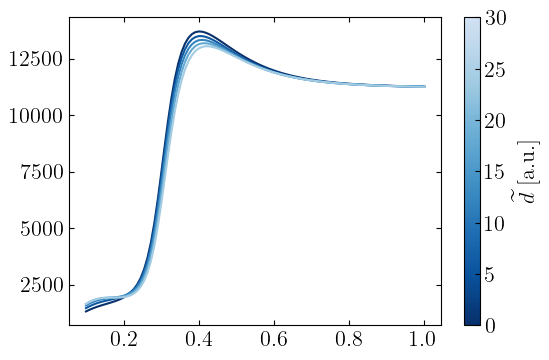

In [4]:
u_per_vals = np.linspace(0,30,5)
C_rates_vals = np.array([0.5, 1, 2, 3, 4, 5])
soc = np.linspace(0.1,1,100)

C = 5
#for C in C_rates_vals:
import matplotlib.colors as mpl_colors
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LinearSegmentedColormap

norm = Normalize(vmin=C_rates_vals.min(), vmax=C_rates_vals.max())
norm_u = Normalize(vmin=0, vmax=30)

fig,ax = plt.subplots(figsize=(6,4))
base = plt.cm.Blues_r
Blues_cut = LinearSegmentedColormap.from_list(
        "Blues_custom", base(np.linspace(0.0, 0.8, 256)))
cmap = Blues_cut

# base = plt.cm.Reds_r
# Reds_cut = LinearSegmentedColormap.from_list(
#         "Reds_custom", base(np.linspace(0.0, 0.8, 256)))
# cmap_r = Reds_cut

for n,u in enumerate(u_per_vals):
    C1_vals = C1_nn(C, u, soc) 
    ax.plot(soc, C1_vals, color=cmap(n/len(u_per_vals)), label=f'u={u:.1f}%')

sm = ScalarMappable(cmap=cmap, norm=norm_u)
fig.colorbar(sm, ax=ax, label=r'$\widetilde{d}$ [a.u.]')


In [5]:
# import matplotlib.colors as mpl_colors
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LinearSegmentedColormap


def plot_element_sweep(model, element, sweep = 'u_per', fixed = 1, sweep_vals = None):
    ''' If sweep 'u_per', then fixed_value is 'C_rate', and vice versa. '''

    if sweep_vals is None:
        if sweep == 'u_per':
            sweep_vals = np.linspace(0,30,5)
        else:
            sweep_vals = np.array([0.5, 1, 2, 3, 4, 5])

    soc = np.linspace(1,0,100)

    if sweep == 'u_per':
        bar_label  = r'$\widetilde{d}$ [%]'
        fixed_tag    = fr'$C = {fixed:g}$'
    elif sweep == 'C_rate':
        bar_label  = 'C-rate [a.u.]'
        fixed_tag    = fr'$\widetilde{{d}} = {fixed:g}\%$'

    norm = Normalize(vmin=C_rates_vals.min(), vmax=C_rates_vals.max())
    norm_u = Normalize(vmin=0, vmax=30)

    fig,ax = plt.subplots(figsize=(6,4))
    base = plt.cm.Blues_r
    Blues_cut = LinearSegmentedColormap.from_list(
            "Blues_custom", base(np.linspace(0.0, 0.8, 256)))
    cmap = Blues_cut

    # base = plt.cm.Reds_r
    # Reds_cut = LinearSegmentedColormap.from_list(
    #         "Reds_custom", base(np.linspace(0.0, 0.8, 256)))
    # cmap_r = Reds_cut



    for n,u in enumerate(u_per_vals):
        C1_vals = C1_nn(C, u, soc) 
        ax.plot(soc, C1_vals, color=cmap(n/len(u_per_vals)), label=f'u={u:.1f}%')

    sm = ScalarMappable(cmap=cmap, norm=norm_u)
    fig.colorbar(sm, ax=ax, label=r'$\widetilde{d}$ [a.u.]')

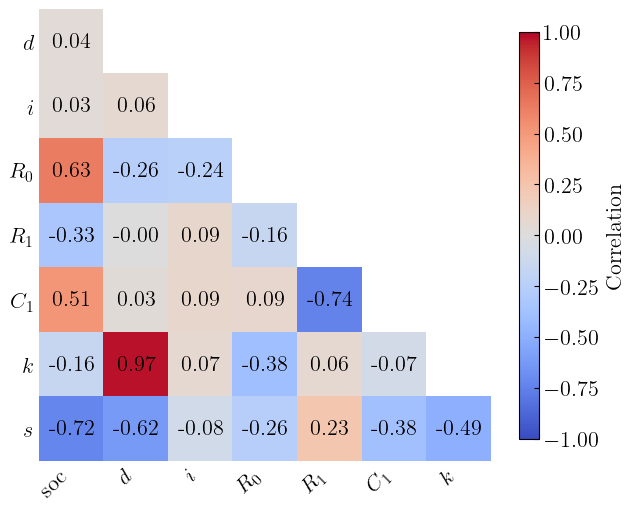

In [6]:
# X = data[['soc','u','I','R0','R1','C1','k','s']].values
# feature_names = ['soc','u','I','R0','R1','C1','k','s']
# with np.errstate(invalid="ignore", divide="ignore"):
#     corr = np.corrcoef(X, rowvar=False)


# fig, ax_corr = plt.subplots(figsize=(7, 5))
# im = ax_corr.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

# ax_corr.set_xticks(np.arange(len(feature_names)))
# ax_corr.set_yticks(np.arange(len(feature_names)))
# ax_corr.set_xticklabels(feature_names, rotation=45, ha="right")
# ax_corr.set_yticklabels(feature_names)
# ax_corr.set_title("Correlation matrix")

# for i in range(corr.shape[0]):
#     for j in range(corr.shape[1]):
#         ax_corr.text(j, i, f"{corr[i, j]:.2f}", ha="center", va="center", color="black")

# fig.colorbar(im, ax=ax_corr, label="Correlation")
# plt.tight_layout()
# plt.show()

X = data[['soc','u_per','C','R0','R1','C1','k','s']].values
feature_names = ['soc', r'$d$', r'$i$', r'$R_0$', r'$R_1$', r'$C_1$', r'$k$', r'$s$']

with np.errstate(invalid="ignore", divide="ignore"):
    corr = np.corrcoef(X, rowvar=False)

# Keep strictly lower triangle (no diagonal)
mask = np.triu(np.ones_like(corr, dtype=bool), k=0)
corr_masked = np.where(mask, np.nan, corr)

# Drop the now-empty first column and last row
corr_trim = corr_masked[1:, :-1]
row_labels = feature_names[1:]
col_labels = feature_names[:-1]

cmap = plt.cm.coolwarm.copy()
cmap.set_bad(color="white")

fig, ax_corr = plt.subplots(figsize=(7, 5), constrained_layout=True)
im = ax_corr.imshow(corr_trim, cmap=cmap, vmin=-1, vmax=1)

ax_corr.set_xticks(np.arange(len(col_labels)))
ax_corr.set_yticks(np.arange(len(row_labels)))
ax_corr.set_xticklabels(col_labels, rotation=45, ha="right")
ax_corr.set_yticklabels(row_labels)
# ax_corr.set_title("Correlation matrix")

for i in range(corr_trim.shape[0]):
    for j in range(corr_trim.shape[1]):
        if not np.isnan(corr_trim[i, j]):
            ax_corr.text(j, i, f"{corr_trim[i, j]:.2f}",
                         ha="center", va="center", color="black")

# Kill the spines
for s in ax_corr.spines.values():
    s.set_visible(False)
ax_corr.tick_params(length=0)  # also remove tick marks

fig.colorbar(im, ax=ax_corr, label="Correlation", shrink=0.9)
#plt.savefig(f'element_corr_matrix.pdf')

In [7]:
df_CC = Param_symbol.read_raw_data('merged_DC_hyper')
df_CC = Param_symbol.read_raw_data('merged_pulse_hyper')
display(df_CC)

,u_par,C,t,V,F,u,Ue,soc,I,trajectory,eta
0,19.1,4.5,0,4.229418,0.078557,-2.745291,4.324996,0.999999,11.200985,0,0.095578
1,19.1,4.5,1,4.118165,0.078575,-2.745291,4.321218,0.998758,22.401970,0,0.203053
2,19.1,4.5,2,4.099471,0.078591,-2.745291,4.317412,0.997508,22.401970,0,0.217940
3,19.1,4.5,3,4.084324,0.078608,-2.745291,4.313605,0.996258,22.401970,0,0.229282
4,19.1,4.5,4,4.071481,0.078625,-2.745291,4.309799,0.995008,22.401970,0,0.238318
...,...,...,...,...,...,...,...,...,...,...,...
227346,17.2,2.5,2723,2.619369,0.080803,-2.472199,3.381726,0.096906,12.445539,74,0.762358
227347,17.2,2.5,2724,2.579749,0.080813,-2.472199,3.379533,0.096211,12.445539,74,0.799784
227348,17.2,2.5,2725,2.532106,0.080822,-2.472199,3.377339,0.095517,12.445539,74,0.845233
227349,17.2,2.5,2726,2.478750,0.080832,-2.472199,3.375146,0.094822,12.445539,74,0.896395


In [8]:
# Extract expressions from symbolic regression results
def extract_expressions(run_id, elements = VARIABLES):
    # Load the symbolic regression results
    
    expressions = {}

    for elem in elements:
    
        results_path = Path(f'sr_models/model_{elem}_{run_id}.csv')
        if not results_path.exists():
            raise FileNotFoundError(f"Results file not found: {results_path}")
    
        results_df = pd.read_csv(results_path)

        expr = results_df['sympy_format']# == int(results_df['complexity'].mean())]
        expressions[elem] = expr

    
    return expressions

print(f"Loading symbolic regression results for RUN_ID: {RUN_ID}")
#res, R0_expr, R1_expr, C1_expr, k_expr, s_expr = extract_expressions(RUN_ID)
expressions = extract_expressions(RUN_ID)
R0_expr = expressions['R0']
R1_expr = expressions['R1']
C1_expr = expressions['C1']
k_expr = expressions['k']
s_expr = expressions['s']

latent_variables = {'x0': 'c-rate', 'x1': 'd_per', 'x2': 'soc', 'x3':'s'}


from collections import Counter
VARIABLES = ['R0', 'R1', 'C1', 'k','s']
symbol_counts = {}
for elem in VARIABLES:
    counter = Counter()
    for expr in expressions[elem]:
        sympy_expr = sp.sympify(expr)

        counter.update(map(str, sympy_expr.free_symbols))

    symbol_counts[elem] = counter

# convert to dataframe for better visualization
symbol_counts_df = pd.DataFrame(symbol_counts).fillna(0).astype(int)

for elem in symbol_counts_df:
    symbol_counts_df[elem] = 100 * symbol_counts_df[elem] / expressions[elem].shape[0]

df_symcounts = symbol_counts_df.transpose()
display(df_symcounts)
print(f'Latent variables: {latent_variables}')
df_symcounts.columns = [latent_variables.get(col, col) for col in df_symcounts.columns]
display(df_symcounts)

# round values to 1 decimal place
df_symcounts = df_symcounts.round(1)

def df_latex_table(df, caption=None, label=None):
    latex_str = df.to_latex(index=True, escape=False)
    if caption:
        latex_str = latex_str.replace('\\begin{tabular}', f'\\begin{{table}}[ht]\n\\centering\n\\caption{{{caption}}}\n\\begin{{tabular}}')
    if label:
        latex_str = latex_str.replace('\\end{tabular}', f'\\end{{tabular}}\n\\label{{{label}}}\n\\end{{table}}')
    return latex_str

latex_table = df_latex_table(df_symcounts, caption="Symbol usage percentages in SR expressions", label="tab:symbol_usage")
print(latex_table)

for sym in expressions['s']:
    sympy_expr = sp.sympify(sym)
    rounded_expr = sympy_expr.xreplace({n: sp.Float(round(float(n), 3)) for n in sympy_expr.atoms(sp.Float)})
    print(f"s = {sp.latex(rounded_expr)}")

Loading symbolic regression results for RUN_ID: SP


,soc,C,d,s
R0,96.000000,80.000000,72.000000,0.0
R1,92.000000,84.000000,0.000000,0.0
C1,96.296296,77.777778,0.000000,0.0
k,78.260870,0.000000,95.652174,0.0
s,25.000000,100.000000,89.285714,75.0


Latent variables: {'x0': 'c-rate', 'x1': 'd_per', 'x2': 'soc', 'x3': 's'}


,soc,C,d,s
R0,96.000000,80.000000,72.000000,0.0
R1,92.000000,84.000000,0.000000,0.0
C1,96.296296,77.777778,0.000000,0.0
k,78.260870,0.000000,95.652174,0.0
s,25.000000,100.000000,89.285714,75.0


\begin{table}[ht]
\centering
\caption{Symbol usage percentages in SR expressions}
\begin{tabular}{lrrrr}
\toprule
 & soc & C & d & s \\
\midrule
R0 & 96.000000 & 80.000000 & 72.000000 & 0.000000 \\
R1 & 92.000000 & 84.000000 & 0.000000 & 0.000000 \\
C1 & 96.300000 & 77.800000 & 0.000000 & 0.000000 \\
k & 78.300000 & 0.000000 & 95.700000 & 0.000000 \\
s & 25.000000 & 100.000000 & 89.300000 & 75.000000 \\
\bottomrule
\end{tabular}
\label{tab:symbol_usage}
\end{table}

s = C
s = e^{C}
s = 3.011 C
s = - d + e^{C}
s = e^{2 C - 2 d}
s = \frac{C}{d^{3} + 0.212}
s = 4.901 C \left(1.062 - d\right)
s = C \left(1.038 - d\right) \left(5.437 - s\right)
s = C \left(1.044 - d\right) \left(5.22 - s^{2}\right)
s = C \left(5.665 - s\right) e^{\left(- d - 0.364\right)^{3}}
s = C \left(- s^{2} + 5.486 e^{\left(- d - 0.356\right)^{3}}\right)
s = 5.289 C e^{\left(- d - 0.335\right)^{3} e^{s^{2}}}
s = 5.312 C e^{\left(- d - 0.344\right)^{3} \left(e^{s^{3}}\right)^{\frac{3}{2}}}
s = \left(5.192 C + 0.05\right

In [9]:
def display_expresions(elem, latent_variables, expressions = expressions, complexity = None, loss = None, ref_values = REF_VALUES):
    latex_dict ={
        'R0': r'R_0',
        'R1': r'R_1',
        'C1': r'C_1',
        'k': r'k',
        's': r'\dot{s}',
    }

    print(f"\nExpression for {elem}:")
    for j,expr in enumerate(expressions[elem]):
        sympy_expr = sp.sympify(expr)
        if complexity is not None:
            #display(Math(f"\\Large {complexity[j]}, idx: {j}: {elem} = {sp.latex(ref_values[elem] * sympy_expr)}"))
            display(Math(f"\\Large {complexity[j]}, idx: {j}: {latex_dict[elem]} = {sp.latex(sympy_expr.evalf(3))}"))
        else:
            display(Math(f"\\Large {j}: {latex_dict[elem]} = {sp.latex(sympy_expr)}"))

sr_models/model_R0_SP.csv


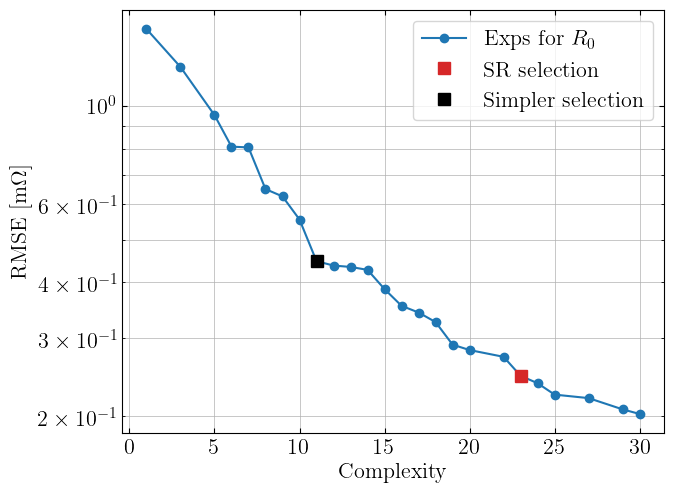

In [67]:
#RUN_ID = '1305_hSOC'

unit_conversion = {
        'R0': 1e3,
        'R1': 1e3,
        'C1': 1e-3,
        'k':  100, # GN/1e-5m * 100 = MN/mum
        's':  0.1  # 1e-5 m/s * 0.1 = mum/s
        }

diff_vals = 1
def post_pareto_plot(elem, run_id, colors = COLORS, diff = diff_vals, ref_values = REF_VALUES, save = SAVE, inds = None, unit_conversion = unit_conversion):
    print(f'sr_models/model_{elem}_{run_id}.csv')
    latex_dict ={
        'R0': r'R_0',
        'R1': r'R_1',
        'C1': r'C_1',
        'k': r'k',
        's': r'\dot{s}',
    }
    units_dict = {
        'R0': r'm$\Omega$',
        'R1': r'm$\Omega$',
        'C1': r'kF',
        'k':  r'MN/µm',
        's':  r'µm/s'
        }

    df_model = pd.read_csv(f'sr_models/model_{elem}_{run_id}.csv')
    best = pd.read_csv(f'sr_models/model_{elem}_best_{run_id}.csv')
    best_complexity = float(best.iloc[0, 0])
    best_rows = df_model[np.isclose(df_model['complexity'], best_complexity)]
    best_ind = int(best.iloc[0,0])
    plt.figure(figsize=(7, 5.5))
    plt.xticks(np.arange(0, df_model['complexity'].max() + 1, 5))
    plt.grid(True, which="both", ls="-", linewidth=0.5)
    # if elem == 'k':
    #     factor = 100
    #     ref_values[elem] = factor * ref_values[elem]
    plt.plot(df_model['complexity'], np.sqrt(df_model['loss']) * ref_values[elem] * unit_conversion[elem], marker='o', linestyle='-', color=colors[0], label=fr'Exps for ${latex_dict[elem]}$', markersize=6)
    plt.plot(best_rows['complexity'],np.sqrt(best_rows['loss']) * ref_values[elem] * unit_conversion[elem], marker='s', linestyle='', color=colors[1], label='SR selection', markersize=8)
    if inds is not None:
        plt.plot(df_model.iloc[inds]['complexity'], np.sqrt(df_model.iloc[inds]['loss']) * ref_values[elem]* unit_conversion[elem], marker='s', linestyle='', color=colors[3], label='Simpler selection', markersize=8)
    #plt.plot(df_model.iloc[0]['complexity'], np.sqrt(df_model.iloc[0]['loss']) * ref_values[elem], marker='o', linestyle='', color=colors[3], label='Constant')
    plt.xlabel('Complexity')
    plt.ylabel(f'RMSE [{units_dict[elem]}]')
    plt.yscale('log')
    plt.legend()
    plt.savefig(f'SR_figs/SP/model_{elem}_{run_id}_pareto.pdf', bbox_inches='tight') if save else None
    plt.show()


# –––– 1405_dark_knight –––– Sigmoid
# chosen_SR = {
#     'R0': 11, # JN
#     'R1': 10, # JN
#     'C1': 13, # JN
#     'k': 8,
#     's': 12
# }
 
# best_SR = {
#     'R0': 14, # JN
#     'R1':26, # JN,
#     'C1': 18, # JN
#     'k': 14, # JN
#     's': 16 # JH
# }
# ––––––––––––––––––––––––––

# –––– 1605_... –––– Softplus
chosen_SR = {
    'R0': 8, # JN
    'R1': 8, # JH
    'C1': 7, # JN
    'k': 7, # JH
    's': 6 # JN
}
 
best_SR = {
    'R0': 19, # JN
    'R1': 19, # JH
    'C1': 24, # JN 
    'k': 22, # JH 
    's': 27 # JN
}

elem = 'R0'
#Param_symbol.post_pareto_plot(elem,run_id=RUN_ID)
RUN_ID = 'SP'
df = pd.read_csv(f'sr_models/model_{elem}_{RUN_ID}.csv')

complexity = df['complexity'].values

post_pareto_plot(elem, RUN_ID, save = True, inds = chosen_SR[elem])

# display_expresions(elem, latent_variables, complexity= complexity)

In [54]:
R0_func = sp.lambdify(('C', 'd', 'soc'), R0_expr[chosen_SR['R0']], 'numpy')
s_func = sp.lambdify(('C', 'd', 'soc','s'), s_expr[chosen_SR['R0']], 'numpy')
R1_func = sp.lambdify(('C', 'd', 'soc'), R1_expr[chosen_SR['R1']], 'numpy')
C1_func = sp.lambdify(('C', 'd', 'soc'), C1_expr[chosen_SR['C1']], 'numpy')
k_func = sp.lambdify(('C', 'd', 'soc'), k_expr[chosen_SR['k']], 'numpy') 


def gen_table(elem, run_id = RUN_ID, expressions = expressions, ref_values = REF_VALUES, unit_conversion = unit_conversion):
    df_R0 =  pd.read_csv(f'sr_models/model_{elem}_{RUN_ID}.csv')

    # df_R0['latex'] = df_R0['sympy_format'].apply(lambda expr: sp.latex(sp.sympify(expr).evalf(3), full_prec=False))

    df_R0['latex'] = df_R0['sympy_format'].apply(lambda expr: f"${sp.latex(sp.sympify(expr).evalf(3), full_prec=False)}$")

    print('latex_table')
    factor = 100
    df_R0['loss'] = np.sqrt(df_R0['loss']) * REF_VALUES[elem] * unit_conversion[elem] if elem == 'k' or elem == 's' else (np.sqrt(df_R0['loss']) * REF_VALUES[elem]* unit_conversion[elem]).round(3)
    table_latex = df_R0[['complexity', 'loss', 'latex']].to_latex(index=False, escape=False, float_format="%.3f")
    print(table_latex)

print('Generating table for C1')
gen_table('k')


for elem in VARIABLES:
    print(f"Chosen expressions for {elem}:")
    expr = sp.sympify(expressions[elem][chosen_SR[elem]])
    rounded_expr = expr.xreplace({n: sp.Float(round(float(n), 3)) for n in expr.atoms(sp.Float)})
    print(f"{elem} = {sp.latex(rounded_expr)}")
    expr = sp.sympify(expressions[elem][best_SR[elem]])
    rounded_expr = expr.xreplace({n: sp.Float(round(float(n), 3)) for n in expr.atoms(sp.Float)})
    print(f"{elem} = {sp.latex(rounded_expr)}")

Generating table for C1
latex_table
\begin{tabular}{rrl}
\toprule
complexity & loss & latex \\
\midrule
1 & 37.740 & $2.89$ \\
3 & 12.320 & $d + 2.39$ \\
4 & 12.241 & $d^{2} + 2.55$ \\
5 & 8.905 & $\frac{6.59}{2.82 - d}$ \\
6 & 8.895 & ${2.28}^{d} + 1.33$ \\
7 & 3.881 & $\frac{7.28 - soc}{2.88 - d}$ \\
8 & 2.590 & $\frac{7.31 - soc^{0.5}}{2.84 - d}$ \\
9 & 0.907 & $\frac{6.58}{- d + 0.23 soc + 2.7}$ \\
10 & 0.868 & $\frac{10.0 - soc}{\left(3.25 - d\right)^{1.2}}$ \\
11 & 0.686 & $-0.399 + \frac{8.49}{- d + 0.233 soc + 3.0}$ \\
12 & 0.644 & $0.416 + \frac{37.2}{\left(- d + 0.233 soc + 4.29\right)^{2}}$ \\
14 & 0.586 & $d - \left(- 0.148 d^{2} + 0.148 soc\right) e^{\sqrt{d}} + 2.42$ \\
15 & 0.463 & $0.497 d + 0.497 \left(- d - 0.789\right) \left(- d + 0.469 soc\right) + 2.43$ \\
16 & 0.394 & $0.211 \left(- 3.41 d^{0.855} + soc\right) \left(- d - 0.93\right) + 2.43$ \\
20 & 0.393 & $0.371 d + 0.21 \left(- 2.46 d + soc^{0.974}\right) \left(- d - 0.943\right) + 2.44$ \\
22 & 0.355 & $0.503 